In [ ]:
# Импорт стандартных библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Отображение графиков прямо в ноутбуке
%matplotlib inline

# Импорт датасета и методов из scikit-learn
from sklearn.datasets import load_iris  # датасет Iris [web:11]
from sklearn.decomposition import PCA   # метод главных компонент [web:14]
from sklearn.manifold import TSNE       # алгоритм t-SNE [web:18]

# Методы кластеризации
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Метрики качества кластеризации [web:16]
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Зафиксируем зерно генератора случайных чисел для воспроизводимости
RANDOM_STATE = 42

# Загрузка датасета Iris из sklearn
iris = load_iris()  # загрузка данных и целевого признака [web:11]
X = iris.data       # матрица признаков (4 признака)
y_true = iris.target  # истинные метки классов (не будем использовать при обучении)

# Преобразуем в DataFrame для удобства
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)

# Для наглядности выведем первые строки датасета
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# Формируем подмножество признаков D1
# Выбираем, например, 3 признака из 4
selected_features = feature_names[:3]  # можно выбрать другие признаки по желанию
D1 = df[selected_features].copy()

print("Выбранные признаки для D1:", selected_features)
D1.head()

Выбранные признаки для D1: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']


,sepal length (cm),sepal width (cm),petal length (cm)
0,5.1,3.5,1.4
1,4.9,3.0,1.4
2,4.7,3.2,1.3
3,4.6,3.1,1.5
4,5.0,3.6,1.4


In [ ]:
# Снижение размерности методом главных компонент (PCA) до 2D [web:14]
pca = PCA(n_components=2, random_state=RANDOM_STATE)
D2 = pca.fit_transform(D1.values)

# Превратим в DataFrame для удобства визуализации
D2_df = pd.DataFrame(D2, columns=['PC1', 'PC2'])

print("Дисперсия, объясненная каждой главной компонентой:", pca.explained_variance_ratio_)
D2_df.head()

Дисперсия, объясненная каждой главной компонентой: [0.92464061 0.06046599]


,PC1,PC2
0,-2.490880,0.320973
1,-2.523343,-0.178401
2,-2.711149,-0.137820
3,-2.557756,-0.315675
4,-2.538964,0.331357


t-SNE - t‑Distributed Stochastic Neighbor Embedding t‑распределённое стохастическое вложение соседей.

t‑SNE – это метод нелинейного снижения размерности, который специально придумали для визуализации сложных многомерных данных в 2D/3D, чтобы кластеры и локальная структура были хорошо видны.

t‑SNE:

В исходном пространстве он для каждой точки оценивает, какие точки считаются её «соседями», и преобразует расстояния в вероятности «быть рядом» (близкие точки – высокая вероятность, далёкие – низкая).

Затем он размещает те же точки в 2D так, чтобы сохранить эти вероятности соседства:

если две точки были соседями в исходном пространстве, он старается поставить их близко и в 2D;

если точки были далеки, он старается раздвинуть их подальше.

In [ ]:
# Снижение размерности методом t-SNE до 2D [web:18]
tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=30,
    learning_rate='auto',
    init='pca'  # хорошая инициализация для t-SNE
)

D3 = tsne.fit_transform(D1.values)

# Оформим тоже в DataFrame
D3_df = pd.DataFrame(D3, columns=['TSNE1', 'TSNE2'])
D3_df.head()

,TSNE1,TSNE2
0,-24.462112,-0.734389
1,-21.555628,0.250168
2,-21.767859,-1.082339
3,-21.271555,-0.669008
4,-24.447025,-1.248012


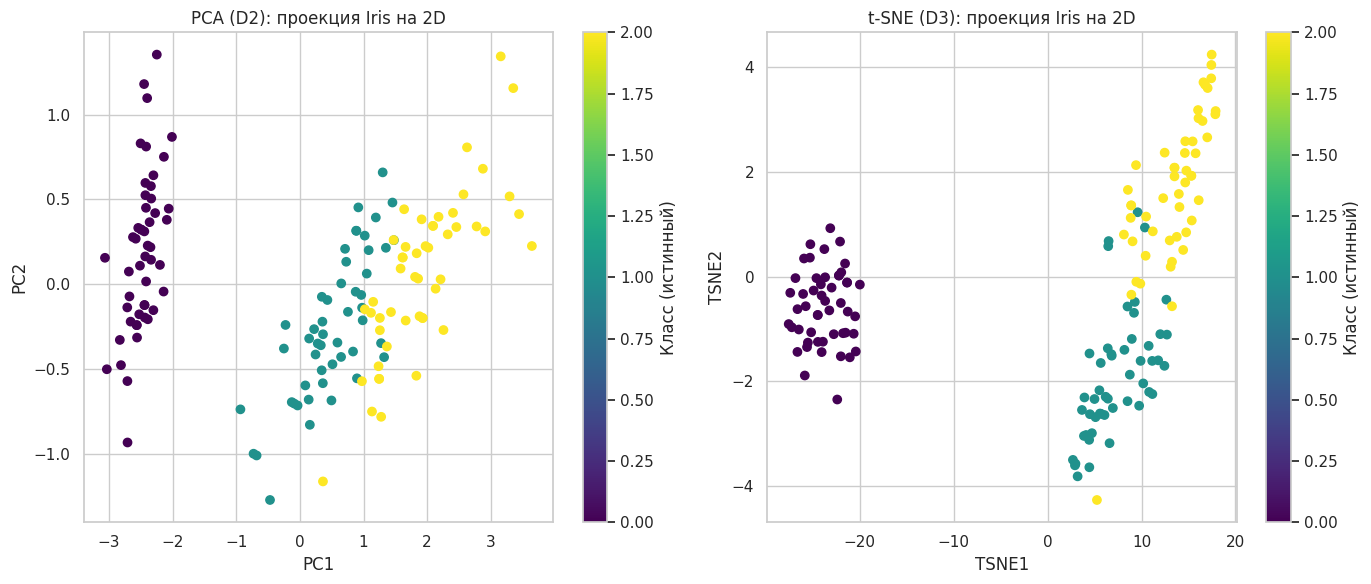

In [ ]:
# Настройки для графиков
sns.set(style="whitegrid", context="notebook")

plt.figure(figsize=(14, 6))

# Визуализация PCA (D2)
plt.subplot(1, 2, 1)
scatter = plt.scatter(D2_df['PC1'], D2_df['PC2'], c=y_true, cmap='viridis')
plt.title('PCA (D2): проекция Iris на 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Класс (истинный)')

# Визуализация t-SNE (D3)
plt.subplot(1, 2, 2)
scatter = plt.scatter(D3_df['TSNE1'], D3_df['TSNE2'], c=y_true, cmap='viridis')
plt.title('t-SNE (D3): проекция Iris на 2D')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.colorbar(scatter, label='Класс (истинный)')

plt.tight_layout()
plt.show()

In [ ]:
def cluster_and_evaluate(X_data, data_name, is_2d=False, coords_names=('X1', 'X2')):
    """
    X_data: np.array или DataFrame с признаками
    data_name: строка для подписи (D1, D2, D3)
    is_2d: True, если данные уже 2-мерные и нужно нарисовать scatter с координатами coords_names
    coords_names: имена координат для 2D визуализации
    """
    print(f"\nКластеризация для {data_name}")

    # Преобразуем к numpy-массиву
    X_arr = np.array(X_data)

    # Словарь алгоритмов кластеризации
    clusterers = {
        'KMeans': KMeans(n_clusters=3, random_state=RANDOM_STATE),
        'Agglomerative': AgglomerativeClustering(n_clusters=3),
        'DBSCAN': DBSCAN(eps=0.5, min_samples=5)
    }

    results = []

    for name, model in clusterers.items():
        # Обучение и предсказание кластеров
        labels = model.fit_predict(X_arr)

        # Для DBSCAN могут быть шумовые точки с меткой -1
        unique_labels = np.unique(labels)
        n_clusters = len(unique_labels[unique_labels != -1]) if -1 in unique_labels else len(unique_labels)

        print(f"\nМетод: {name}")
        print("Количество кластеров (без шума для DBSCAN):", n_clusters)

        # Если у нас только один кластер или все точки - шум, метрики не определены
        if n_clusters <= 1:
            print("Недостаточно кластеров для вычисления метрик.")
            results.append({
                'method': name,
                'n_clusters': n_clusters,
                'silhouette': np.nan,
                'davies_bouldin': np.nan,
                'calinski_harabasz': np.nan
            })
        else:
            # Метрика силуэта: чем ближе к 1, тем лучше разделены кластеры [web:16]
            silhouette = silhouette_score(X_arr, labels)
            # Индекс Дэвиса–Болдина: чем МЕНЬШЕ, тем лучше
            db_index = davies_bouldin_score(X_arr, labels)
            # Индекс Калински–Харабаса: чем БОЛЬШЕ, тем лучше
            ch_index = calinski_harabasz_score(X_arr, labels)

            print("Silhouette score:", silhouette)
            print("Davies-Bouldin index:", db_index)
            print("Calinski-Harabasz index:", ch_index)

            results.append({
                'method': name,
                'n_clusters': n_clusters,
                'silhouette': silhouette,
                'davies_bouldin': db_index,
                'calinski_harabasz': ch_index
            })

        # Визуализация только для 2D данных
        if is_2d:
            plt.figure(figsize=(5, 4))
            scatter = plt.scatter(X_arr[:, 0], X_arr[:, 1], c=labels, cmap='tab10')
            plt.title(f'{data_name}: {name}')
            plt.xlabel(coords_names[0])
            plt.ylabel(coords_names[1])
            plt.colorbar(scatter, label='Кластер')
            plt.show()

    # Соберём результаты в DataFrame для удобного сравнения
    results_df = pd.DataFrame(results)
    return results_df

In [ ]:
results_D1 = cluster_and_evaluate(D1, data_name='D1 (исходные признаки)', is_2d=False)
results_D1


=== Кластеризация для D1 (исходные признаки) ===

Метод: KMeans
Количество кластеров (без шума для DBSCAN): 3
Silhouette score: 0.5498955810221875
Davies-Bouldin index: 0.6576561266485874
Calinski-Harabasz index: 556.1703613698259

Метод: Agglomerative
Количество кластеров (без шума для DBSCAN): 3
Silhouette score: 0.5188656086471253
Davies-Bouldin index: 0.6451570194954053
Calinski-Harabasz index: 493.693271807737

Метод: DBSCAN
Количество кластеров (без шума для DBSCAN): 2
Silhouette score: 0.5291251375422291
Davies-Bouldin index: 3.9935414936399987
Calinski-Harabasz index: 220.75564264854702


,method,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,3,0.549896,0.657656,556.170361
1,Agglomerative,3,0.518866,0.645157,493.693272
2,DBSCAN,2,0.529125,3.993541,220.755643



=== Кластеризация для D2 (PCA, 2D) ===

Метод: KMeans
Количество кластеров (без шума для DBSCAN): 3
Silhouette score: 0.5835695249259651
Davies-Bouldin index: 0.5912680557944935
Calinski-Harabasz index: 637.4573645967226


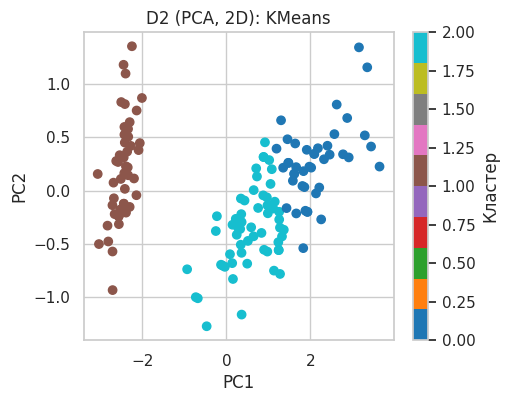


Метод: Agglomerative
Количество кластеров (без шума для DBSCAN): 3
Silhouette score: 0.5494253668531741
Davies-Bouldin index: 0.5599547220221269
Calinski-Harabasz index: 541.3393495452397


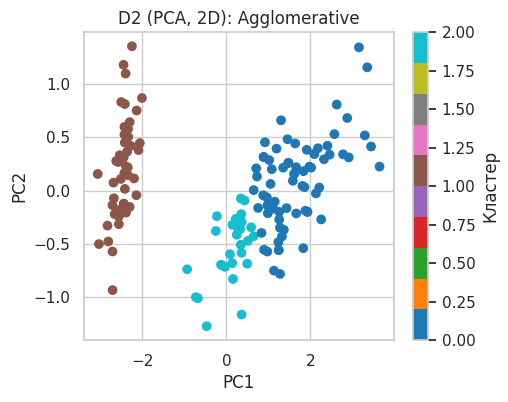


Метод: DBSCAN
Количество кластеров (без шума для DBSCAN): 2
Silhouette score: 0.5800878851021737
Davies-Bouldin index: 3.077838703262993
Calinski-Harabasz index: 270.74525658260046


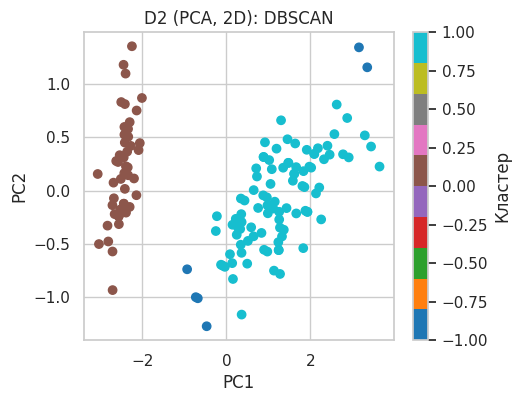

,method,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,3,0.583570,0.591268,637.457365
1,Agglomerative,3,0.549425,0.559955,541.339350
2,DBSCAN,2,0.580088,3.077839,270.745257


In [ ]:
results_D2 = cluster_and_evaluate(
    D2_df[['PC1', 'PC2']],
    data_name='D2 (PCA, 2D)',
    is_2d=True,
    coords_names=('PC1', 'PC2')
)
results_D2


=== Кластеризация для D3 (t-SNE, 2D) ===

Метод: KMeans
Количество кластеров (без шума для DBSCAN): 3
Silhouette score: 0.6714548
Davies-Bouldin index: 0.44921777784351474
Calinski-Harabasz index: 3015.7695


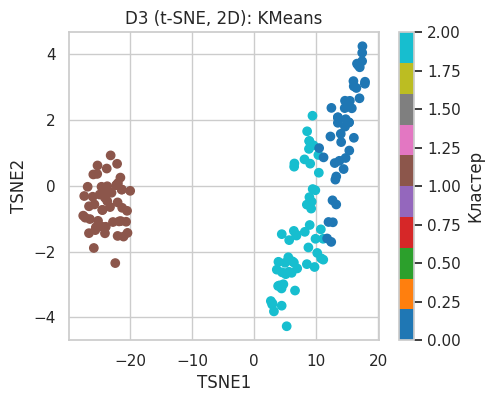


Метод: Agglomerative
Количество кластеров (без шума для DBSCAN): 3
Silhouette score: 0.67311037
Davies-Bouldin index: 0.44584808728029035
Calinski-Harabasz index: 2992.4407


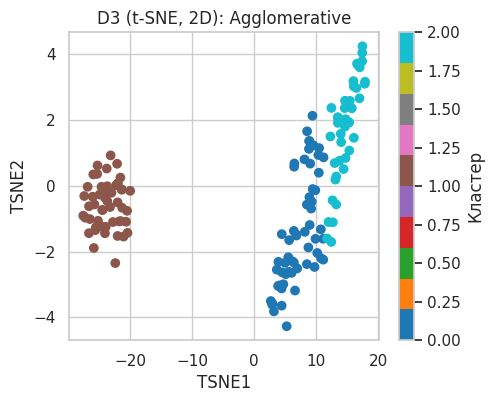


Метод: DBSCAN
Количество кластеров (без шума для DBSCAN): 1
Недостаточно кластеров для вычисления метрик.


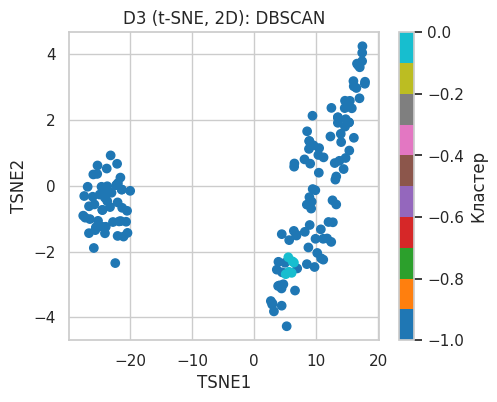

,method,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,3,0.671455,0.449218,3015.769531
1,Agglomerative,3,0.673110,0.445848,2992.440674
2,DBSCAN,1,NaN,NaN,NaN


In [ ]:
results_D3 = cluster_and_evaluate(
    D3_df[['TSNE1', 'TSNE2']],
    data_name='D3 (t-SNE, 2D)',
    is_2d=True,
    coords_names=('TSNE1', 'TSNE2')
)
results_D3

In [ ]:
# Добавим колонку с названием датасета и объединим
results_D1['dataset'] = 'D1'
results_D2['dataset'] = 'D2'
results_D3['dataset'] = 'D3'

all_results = pd.concat([results_D1, results_D2, results_D3], ignore_index=True)
all_results

,method,n_clusters,silhouette,davies_bouldin,calinski_harabasz,dataset
0,KMeans,3,0.549896,0.657656,556.170361,D1
1,Agglomerative,3,0.518866,0.645157,493.693272,D1
2,DBSCAN,2,0.529125,3.993541,220.755643,D1
3,KMeans,3,0.583570,0.591268,637.457365,D2
4,Agglomerative,3,0.549425,0.559955,541.339350,D2
5,DBSCAN,2,0.580088,3.077839,270.745257,D2
6,KMeans,3,0.671455,0.449218,3015.769531,D3
7,Agglomerative,3,0.673110,0.445848,2992.440674,D3
8,DBSCAN,1,NaN,NaN,NaN,D3
